
DOCUMENT IMAGE PROCESSING DEMONSTRATION
Topics: CV & IP Concepts, Document Analysis, Thresholding, Histogram

✅ All operations use mathematical formulas from scratch
✅ Supports any image format (JPG, PNG, BMP, TIFF, GIF, WEBP, PGM)
✅ Auto-resizes to 720p max


📤 Please upload an image:
Click 'Choose File' button below and select your image
Or press 'Cancel' to use test document image
--------------------------------------------------


Saving 6.jpg to 6.jpg

✓ Loaded: 6.jpg (408x612)

1. COMPUTER VISION & IMAGE PROCESSING

1. COMPUTER VISION & IMAGE PROCESSING CONCEPTS

[1] Image as Mathematical Function: f(x,y) → intensity
    ✓ Image represented as mathematical function

[2] Neighborhood Operations
    ✓ 3x3 neighborhood highlighted

[3] Point Operations (Pixel-wise)
    ✓ Point-wise operation: I'(x,y) = I(x,y) + 50

[4] Local Operations
    ✓ Local operation: Sobel edge detection

[5] Global Operations
    ✓ Global operation: histogram equalization

[6] Image Transformations
    ✓ Geometric transformation: rotation


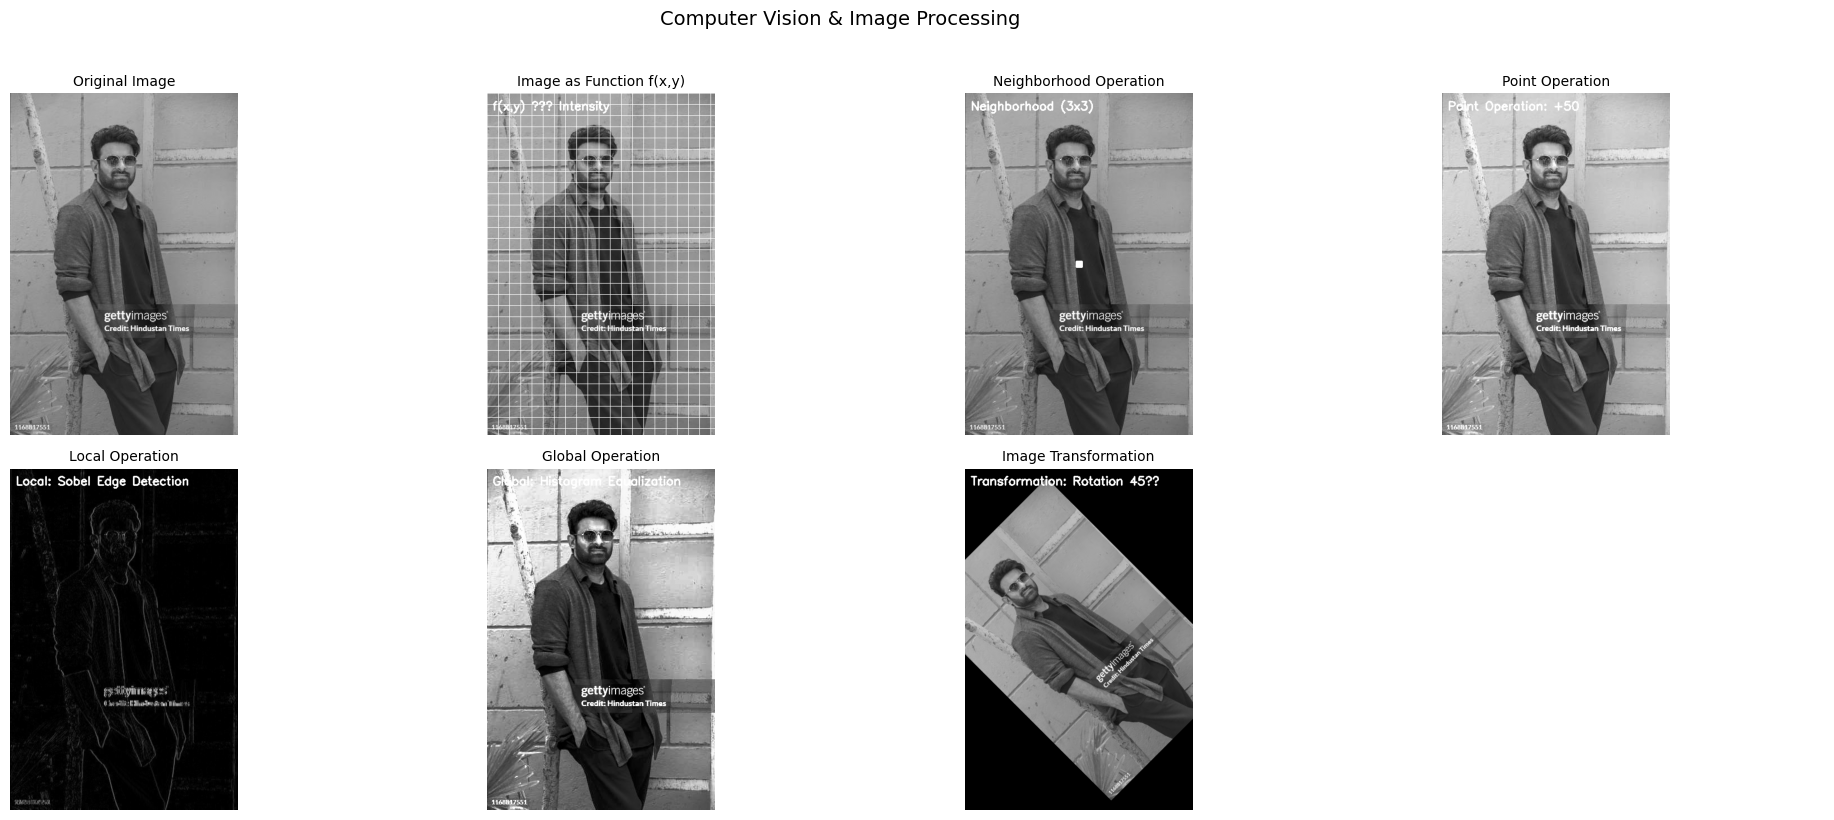


2. DOCUMENT IMAGE ANALYSIS

2. DOCUMENT IMAGE ANALYSIS

[1] Document Preprocessing
    ✓ Noise removal and contrast enhancement

[2] Skew Detection & Correction
    ✓ Skewed document created
    ✓ Skew corrected (angle: -0.82°)

[3] Text Region Detection
    ✓ Text regions detected using morphological operations

[4] Line Segmentation
    ✓ 1 lines detected

[5] Character Segmentation
    ✓ 1 characters detected


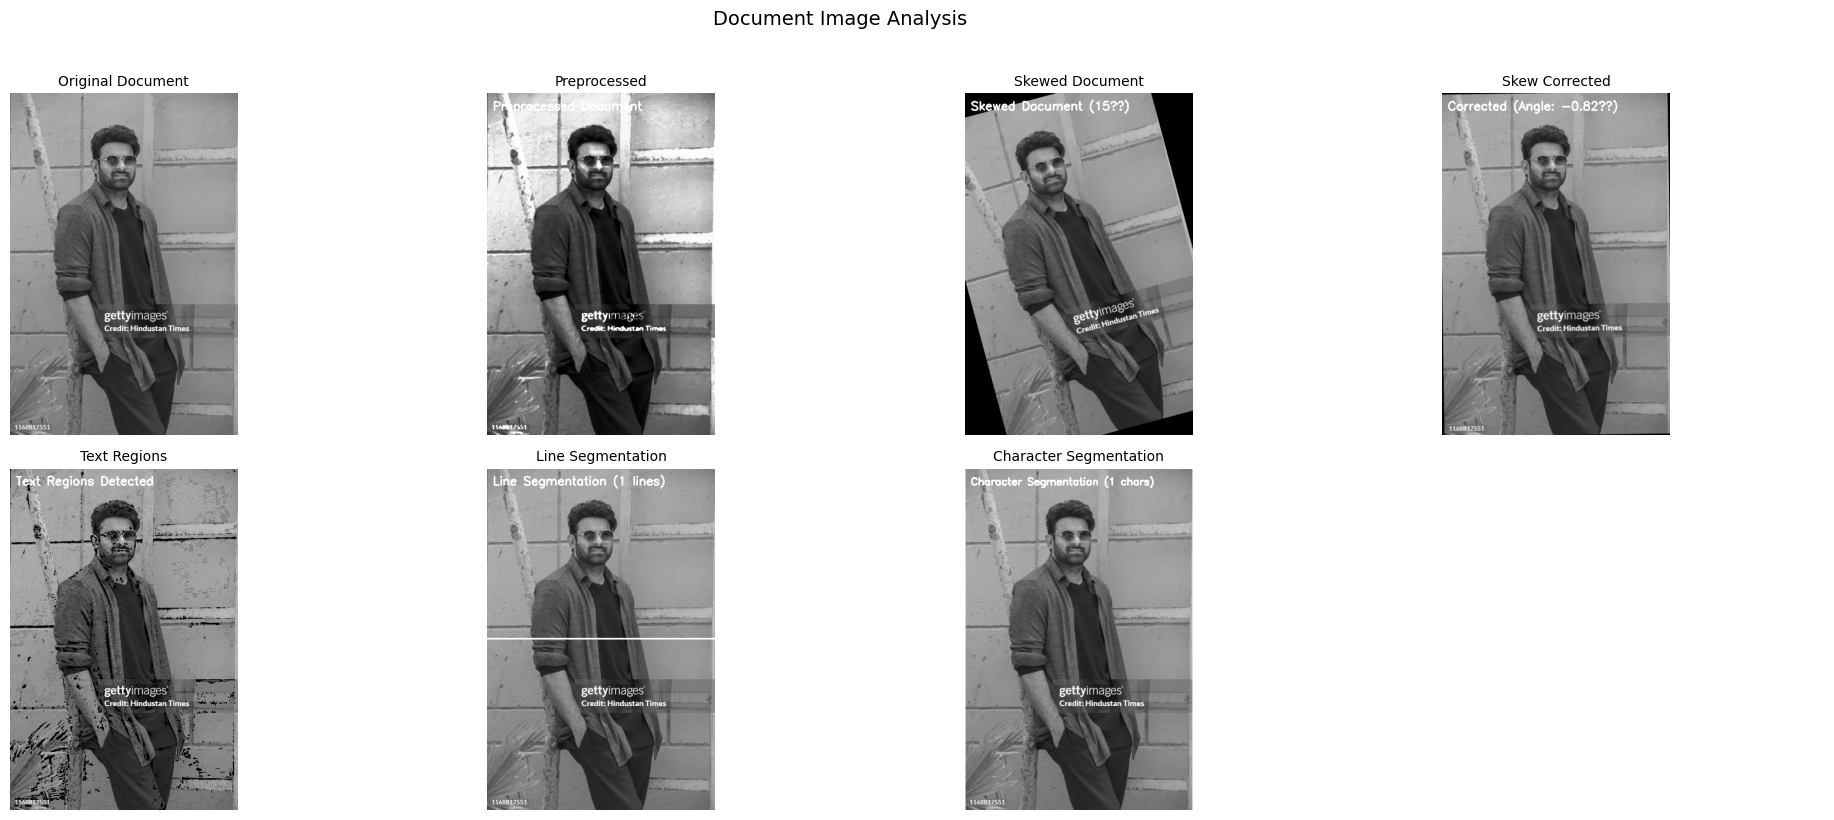


3. IMAGE BINARIZATION (THRESHOLDING)

3. IMAGE BINARIZATION (THRESHOLDING)

[1] Global Thresholding
    ✓ Global thresholding with multiple thresholds

[2] Otsu Thresholding
    ✓ Otsu threshold: T=107.0

[3] Adaptive Thresholding
    ✓ Adaptive thresholding (Mean and Gaussian)

[4] Local Thresholding
    ✓ Niblack local thresholding

[5] Multi-level Thresholding
    ✓ Multi-level thresholding (3 levels)

[6] Thresholding Comparison
    ✓ Comparison of different thresholding methods


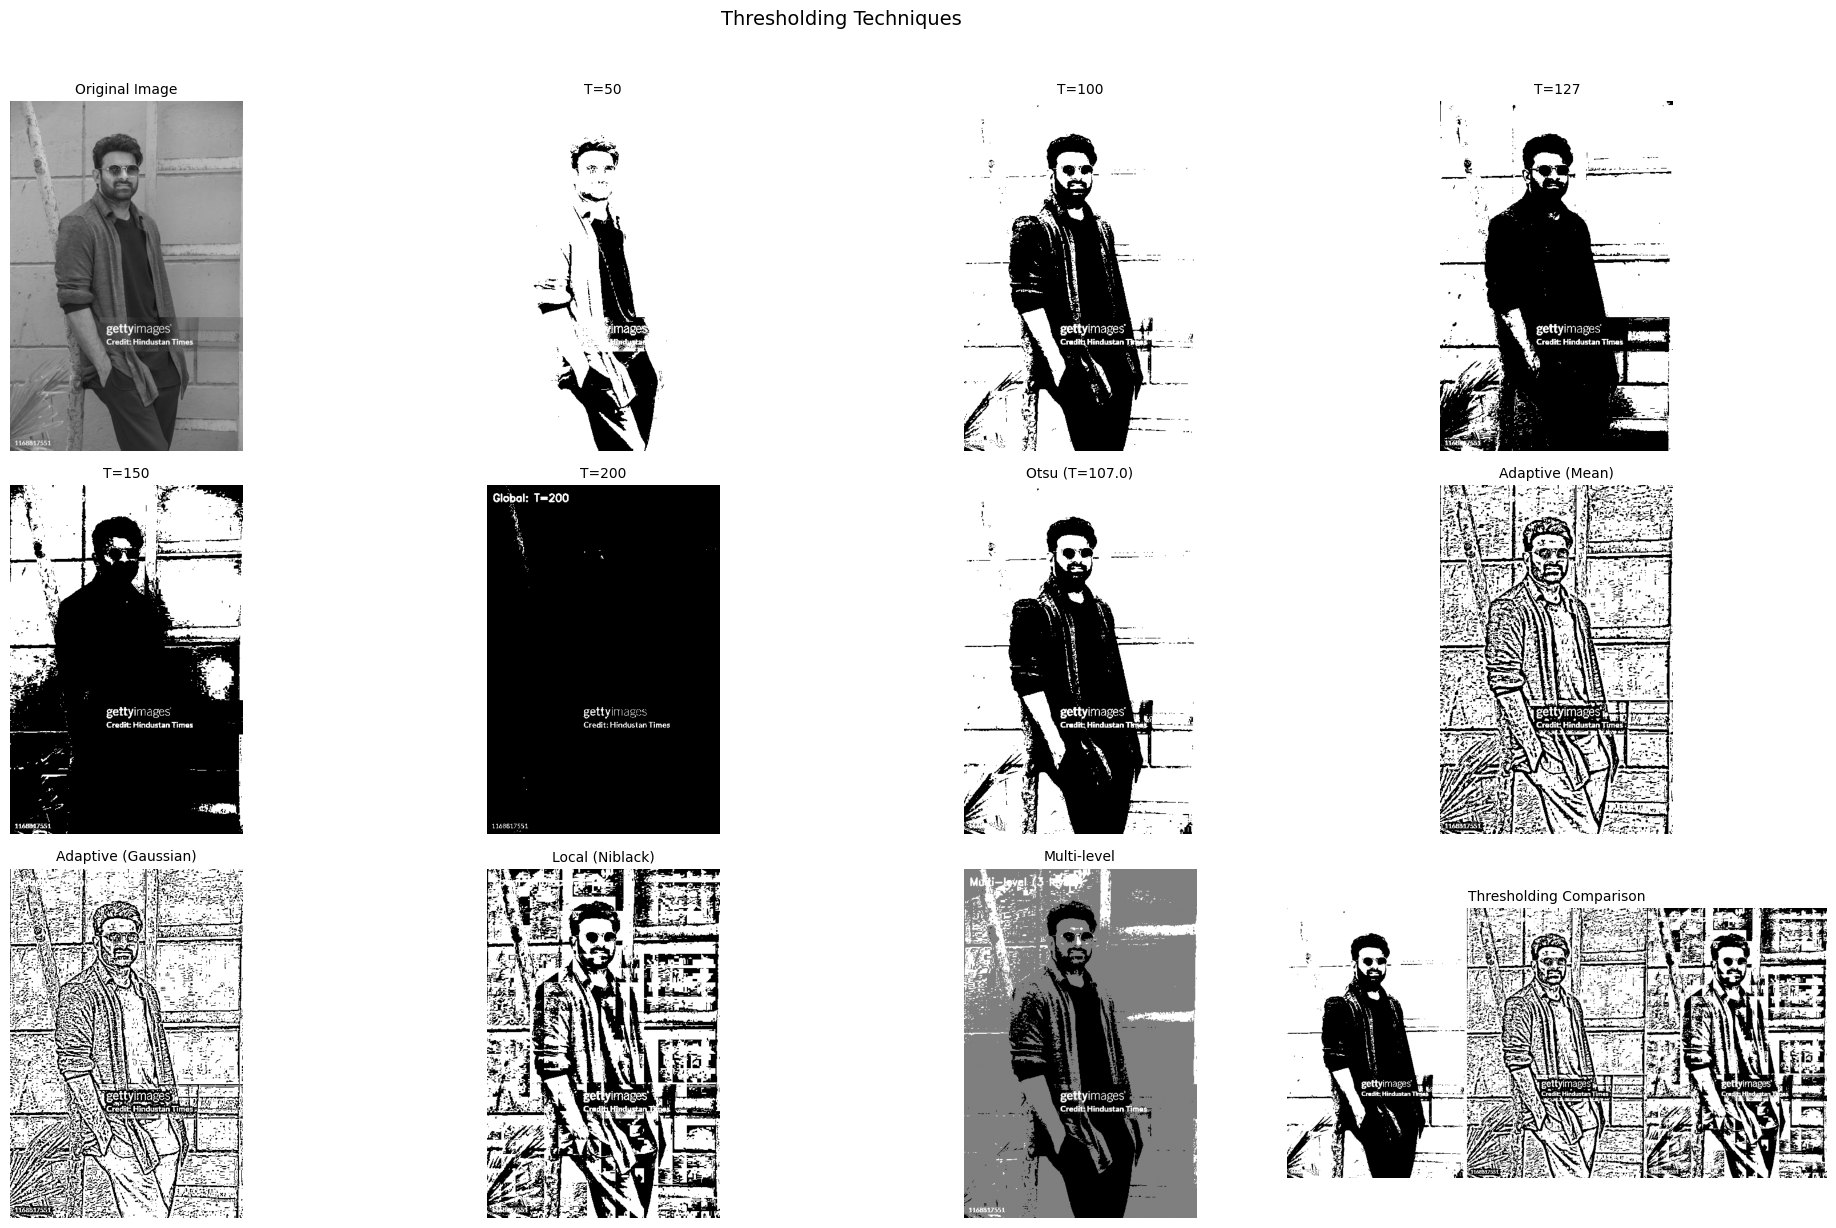


4. HISTOGRAM ANALYSIS

4. HISTOGRAM ANALYSIS

[1] Histogram Computation
    ✓ Histogram computed using formula: h(r_k) = n_k

[2] Histogram Properties
    ✓ Histogram properties: Mean=122.58, Std=44.66

[3] Histogram Equalization
    ✓ Histogram equalization: s = T(r) = (L-1) * Σ p_r(j)
    ✓ Equalized histogram created

[4] Histogram Matching
    ✓ Histogram matching to Gaussian target

[5] Histogram Analysis for Quality
    ✓ Image quality analysis: Contrast=44.66

[6] Histogram Comparison
    ✓ Histogram comparison created


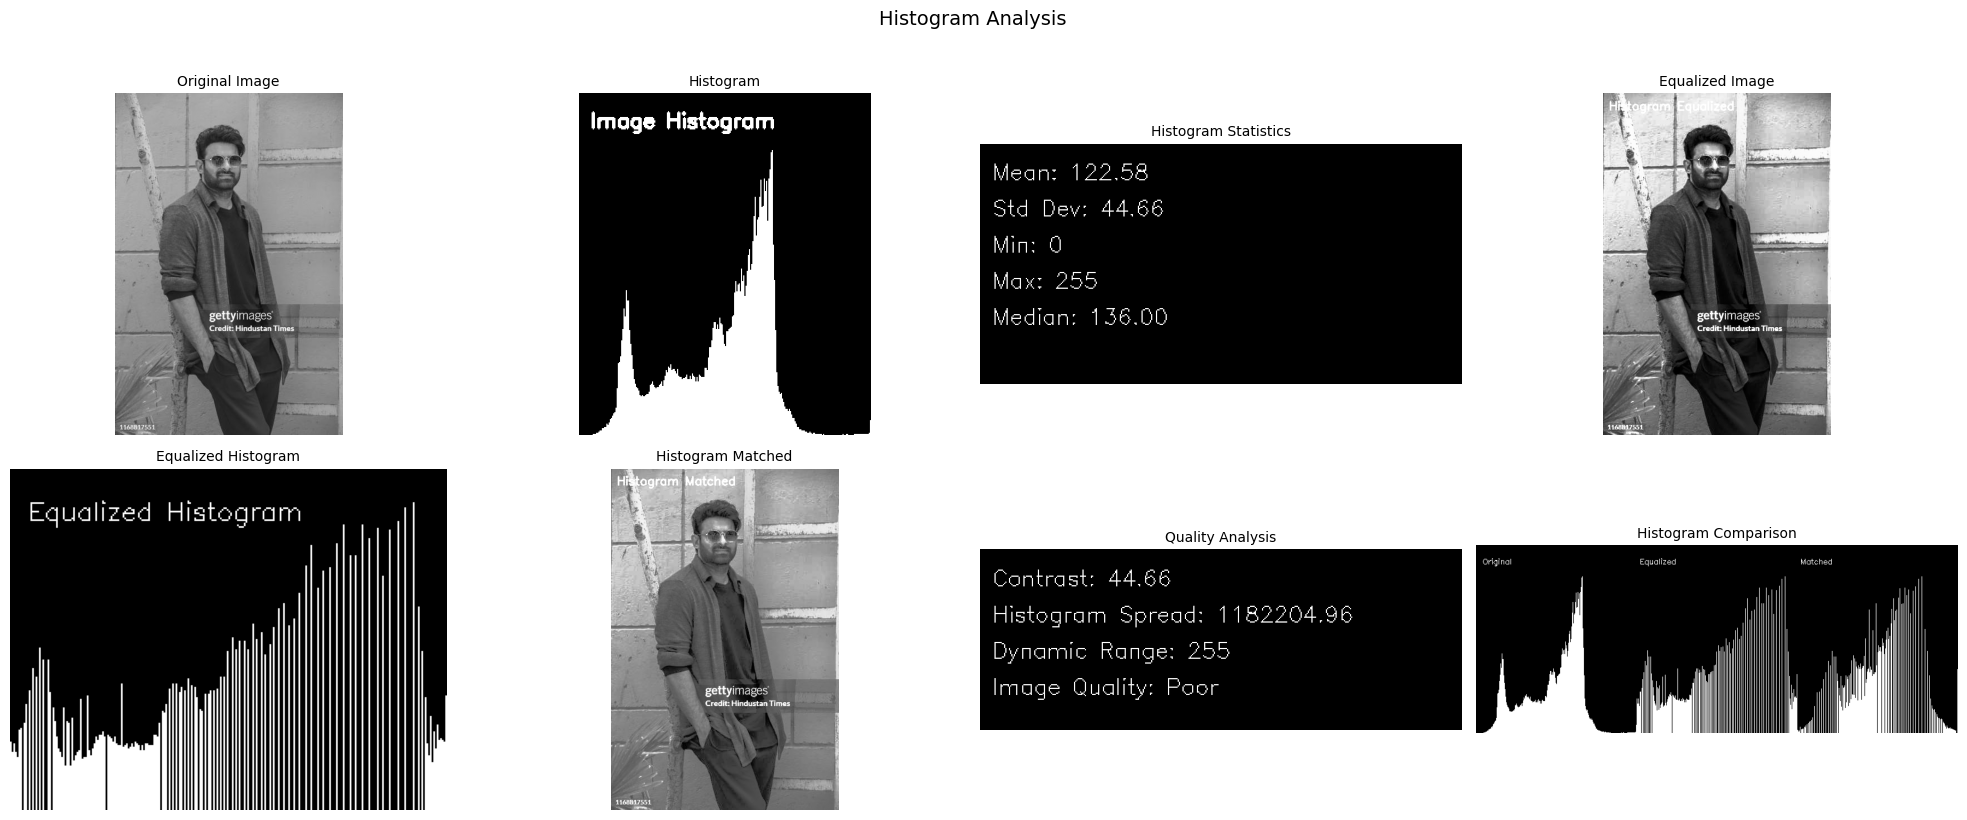


SUMMARY OF ALL DEMONSTRATIONS

1. Computer Vision & Image Processing Concepts:
   - Image as Function: f(x,y) → intensity
   - Neighborhood Operations: convolution
   - Point Operations: pixel-wise processing
   - Local Operations: edge detection
   - Global Operations: histogram equalization
   - Transformations: geometric

2. Document Image Analysis:
   - Preprocessing: noise removal, contrast enhancement
   - Skew Detection & Correction: angle detection
   - Text Region Detection: morphological operations
   - Line Segmentation: horizontal projection
   - Character Segmentation: vertical projection

3. Image Binarization (Thresholding):
   - Global: fixed threshold
   - Otsu: automatic optimal threshold
   - Adaptive: local thresholding
   - Local: Niblack method
   - Multi-level: multiple thresholds

4. Histogram Analysis:
   - Histogram: h(r_k) = n_k
   - Properties: mean, std, min, max
   - Equalization: s = T(r) = (L-1) * Σ p_r(j)
   - Matching: histogram specification
   - Qua

In [ ]:
# ==================== GOOGLE COLAB VERSION ====================
# Run this entire cell in Google Colab

!pip install opencv-python matplotlib pillow scipy scikit-image -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image
from time import time
import math
from scipy import ndimage
from skimage import exposure

# ==================== 1. COMPUTER VISION & IMAGE PROCESSING ====================

def demonstrate_cv_ip_concepts(img):
    """
    Demonstrate fundamental Computer Vision and Image Processing concepts:
    1. Image as Function
    2. Neighborhood Operations
    3. Point Operations
    4. Local Operations
    5. Global Operations
    """
    print("\n" + "="*70)
    print("1. COMPUTER VISION & IMAGE PROCESSING CONCEPTS")
    print("="*70)

    results = []
    titles = []

    # Original image
    results.append(img)
    titles.append("Original Image")

    # 1. Image as Function: f(x,y) → intensity
    print("\n[1] Image as Mathematical Function: f(x,y) → intensity")
    # Create visualization of image as 3D surface
    h, w = img.shape
    # Create a 3D surface plot visualization
    surface_img = img.copy()
    # Add grid lines
    for i in range(0, h, 20):
        cv2.line(surface_img, (0, i), (w, i), 255, 1)
    for j in range(0, w, 20):
        cv2.line(surface_img, (j, 0), (j, h), 255, 1)
    cv2.putText(surface_img, "f(x,y) → Intensity", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(surface_img)
    titles.append("Image as Function f(x,y)")
    print(f"    ✓ Image represented as mathematical function")

    # 2. Neighborhood Operations (Convolution)
    print("\n[2] Neighborhood Operations")
    # Show 3x3 neighborhood
    neighbor_img = img.copy()
    # Mark a pixel and its neighborhood
    center_x, center_y = w//2, h//2
    cv2.circle(neighbor_img, (center_x, center_y), 5, 255, -1)  # Center pixel
    cv2.rectangle(neighbor_img, (center_x-5, center_y-5), (center_x+5, center_y+5), 255, 2)
    cv2.putText(neighbor_img, "Neighborhood (3x3)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(neighbor_img)
    titles.append("Neighborhood Operation")
    print(f"    ✓ 3x3 neighborhood highlighted")

    # 3. Point Operations
    print("\n[3] Point Operations (Pixel-wise)")
    # Show point operation: each pixel processed independently
    point_op = cv2.add(img, 50)  # Brightness increase
    cv2.putText(point_op, "Point Operation: +50", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(point_op)
    titles.append("Point Operation")
    print(f"    ✓ Point-wise operation: I'(x,y) = I(x,y) + 50")

    # 4. Local Operations
    print("\n[4] Local Operations")
    # Apply local operation: edge detection
    local_op = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    local_op = np.abs(local_op)
    local_op = (local_op / np.max(local_op) * 255).astype(np.uint8)
    cv2.putText(local_op, "Local: Sobel Edge Detection", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(local_op)
    titles.append("Local Operation")
    print(f"    ✓ Local operation: Sobel edge detection")

    # 5. Global Operations
    print("\n[5] Global Operations")
    # Apply global operation: histogram equalization
    global_op = cv2.equalizeHist(img)
    cv2.putText(global_op, "Global: Histogram Equalization", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(global_op)
    titles.append("Global Operation")
    print(f"    ✓ Global operation: histogram equalization")

    # 6. Image Transformations
    print("\n[6] Image Transformations")
    # Geometric transformation: rotation
    M = cv2.getRotationMatrix2D((w/2, h/2), 45, 0.8)
    transformed = cv2.warpAffine(img, M, (w, h))
    cv2.putText(transformed, "Transformation: Rotation 45°", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(transformed)
    titles.append("Image Transformation")
    print(f"    ✓ Geometric transformation: rotation")

    return results, titles

# ==================== 2. DOCUMENT IMAGE ANALYSIS ====================

def demonstrate_document_analysis(img):
    """
    Demonstrate Document Image Analysis techniques:
    1. Document Preprocessing
    2. Skew Detection & Correction
    3. Text Region Detection
    4. Line Segmentation
    5. Character Segmentation
    """
    print("\n" + "="*70)
    print("2. DOCUMENT IMAGE ANALYSIS")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Document")

    # 1. Document Preprocessing
    print("\n[1] Document Preprocessing")
    # Remove noise
    denoised = cv2.medianBlur(img, 3)
    # Enhance contrast
    enhanced = cv2.equalizeHist(denoised)
    cv2.putText(enhanced, "Preprocessed Document", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(enhanced)
    titles.append("Preprocessed")
    print(f"    ✓ Noise removal and contrast enhancement")

    # 2. Skew Detection and Correction
    print("\n[2] Skew Detection & Correction")
    # Create skewed version
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w/2, h/2), 15, 1)
    skewed = cv2.warpAffine(img, M, (w, h))
    cv2.putText(skewed, "Skewed Document (15°)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(skewed)
    titles.append("Skewed Document")
    print(f"    ✓ Skewed document created")

    # Correct skew using Hough Transform
    edges = cv2.Canny(img, 50, 150, apertureSize=3)
    lines = cv2.HoughLines(edges, 1, np.pi/180, 100)
    if lines is not None:
        angle = 0
        for line in lines:
            rho, theta = line[0]
            angle_deg = np.degrees(theta) - 90
            if abs(angle_deg) < 45:
                angle += angle_deg
        angle = angle / len(lines) if len(lines) > 0 else 0
        M = cv2.getRotationMatrix2D((w/2, h/2), -angle, 1)
        corrected = cv2.warpAffine(img, M, (w, h))
        cv2.putText(corrected, f"Corrected (Angle: {angle:.2f}°)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
        results.append(corrected)
        titles.append("Skew Corrected")
        print(f"    ✓ Skew corrected (angle: {angle:.2f}°)")

    # 3. Text Region Detection
    print("\n[3] Text Region Detection")
    # Morphological operations to detect text regions
    kernel = np.ones((5, 5), np.uint8)
    dilated = cv2.dilate(img, kernel, iterations=1)
    eroded = cv2.erode(dilated, kernel, iterations=1)
    text_regions = cv2.bitwise_and(img, eroded)
    cv2.putText(text_regions, "Text Regions Detected", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(text_regions)
    titles.append("Text Regions")
    print(f"    ✓ Text regions detected using morphological operations")

    # 4. Line Segmentation
    print("\n[4] Line Segmentation")
    # Horizontal projection for line segmentation
    h_projection = np.sum(img, axis=1)
    line_img = img.copy()
    # Detect lines
    threshold = np.max(h_projection) * 0.1
    lines_pos = []
    for i in range(len(h_projection)):
        if h_projection[i] > threshold:
            lines_pos.append(i)

    # Group lines
    line_groups = []
    if lines_pos:
        current_group = [lines_pos[0]]
        for i in range(1, len(lines_pos)):
            if lines_pos[i] - lines_pos[i-1] < 3:
                current_group.append(lines_pos[i])
            else:
                line_groups.append(current_group)
                current_group = [lines_pos[i]]
        line_groups.append(current_group)

    # Draw lines
    for group in line_groups:
        if len(group) > 0:
            y = int(np.mean(group))
            cv2.line(line_img, (0, y), (w, y), 255, 2)

    cv2.putText(line_img, f"Line Segmentation ({len(line_groups)} lines)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(line_img)
    titles.append("Line Segmentation")
    print(f"    ✓ {len(line_groups)} lines detected")

    # 5. Character Segmentation
    print("\n[5] Character Segmentation")
    # Vertical projection for character segmentation
    v_projection = np.sum(img, axis=0)
    char_img = img.copy()
    # Detect characters
    threshold_char = np.max(v_projection) * 0.1
    char_pos = []
    for i in range(len(v_projection)):
        if v_projection[i] > threshold_char:
            char_pos.append(i)

    # Group characters
    char_groups = []
    if char_pos:
        current_group = [char_pos[0]]
        for i in range(1, len(char_pos)):
            if char_pos[i] - char_pos[i-1] < 2:
                current_group.append(char_pos[i])
            else:
                char_groups.append(current_group)
                current_group = [char_pos[i]]
        char_groups.append(current_group)

    # Draw character bounding boxes
    for group in char_groups:
        if len(group) > 1:
            x1 = group[0]
            x2 = group[-1]
            cv2.rectangle(char_img, (x1, 0), (x2, h), 255, 1)

    cv2.putText(char_img, f"Character Segmentation ({len(char_groups)} chars)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 2)
    results.append(char_img)
    titles.append("Character Segmentation")
    print(f"    ✓ {len(char_groups)} characters detected")

    return results, titles

# ==================== 3. IMAGE BINARIZATION (THRESHOLDING) ====================

def demonstrate_thresholding(img):
    """
    Demonstrate various thresholding techniques:
    1. Global Thresholding
    2. Otsu Thresholding
    3. Adaptive Thresholding
    4. Local Thresholding
    5. Multi-level Thresholding
    """
    print("\n" + "="*70)
    print("3. IMAGE BINARIZATION (THRESHOLDING)")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # 1. Global Thresholding
    print("\n[1] Global Thresholding")
    # Try different threshold values
    thresholds = [50, 100, 127, 150, 200]
    for thresh in thresholds:
        _, binary = cv2.threshold(img, thresh, 255, cv2.THRESH_BINARY)
        cv2.putText(binary, f"Global: T={thresh}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 2)
        results.append(binary)
        titles.append(f"T={thresh}")
    print(f"    ✓ Global thresholding with multiple thresholds")

    # 2. Otsu Thresholding
    print("\n[2] Otsu Thresholding")
    # Otsu's method - automatically finds optimal threshold
    _, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cv2.putText(otsu, f"Otsu (T={_})", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(otsu)
    titles.append(f"Otsu (T={_})")
    print(f"    ✓ Otsu threshold: T={_}")

    # 3. Adaptive Thresholding
    print("\n[3] Adaptive Thresholding")
    # Adaptive mean thresholding
    adaptive_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                          cv2.THRESH_BINARY, 11, 2)
    cv2.putText(adaptive_mean, "Adaptive (Mean)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 2)
    results.append(adaptive_mean)
    titles.append("Adaptive (Mean)")

    # Adaptive Gaussian thresholding
    adaptive_gaussian = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                              cv2.THRESH_BINARY, 11, 2)
    cv2.putText(adaptive_gaussian, "Adaptive (Gaussian)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 2)
    results.append(adaptive_gaussian)
    titles.append("Adaptive (Gaussian)")
    print(f"    ✓ Adaptive thresholding (Mean and Gaussian)")

    # 4. Local Thresholding (Niblack)
    print("\n[4] Local Thresholding")
    # Manual Niblack thresholding
    h, w = img.shape
    niblack = np.zeros_like(img)
    window_size = 25
    k = -0.2

    for i in range(0, h, window_size):
        for j in range(0, w, window_size):
            window = img[i:min(i+window_size, h), j:min(j+window_size, w)]
            mean = np.mean(window)
            std = np.std(window)
            threshold = mean + k * std
            local_binary = (window > threshold).astype(np.uint8) * 255
            niblack[i:min(i+window_size, h), j:min(j+window_size, w)] = local_binary

    cv2.putText(niblack, "Local (Niblack)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 2)
    results.append(niblack)
    titles.append("Local (Niblack)")
    print(f"    ✓ Niblack local thresholding")

    # 5. Multi-level Thresholding
    print("\n[5] Multi-level Thresholding")
    # Multi-level thresholding (3 levels)
    levels = 3
    step = 256 // levels
    multi_level = np.zeros_like(img)
    for i in range(levels):
        lower = i * step
        upper = (i + 1) * step
        if i == levels - 1:
            mask = (img >= lower) & (img <= upper)
        else:
            mask = (img >= lower) & (img < upper)
        multi_level[mask] = (i * 255) // (levels - 1)

    cv2.putText(multi_level, f"Multi-level ({levels} levels)", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 2)
    results.append(multi_level)
    titles.append("Multi-level")
    print(f"    ✓ Multi-level thresholding ({levels} levels)")

    # 6. Comparison of Thresholding Methods
    print("\n[6] Thresholding Comparison")
    # Create comparison image
    comparison = np.zeros((h, w*3), dtype=np.uint8)
    comparison[:, :w] = otsu
    comparison[:, w:2*w] = adaptive_mean
    comparison[:, 2*w:3*w] = niblack

    cv2.putText(comparison, "Otsu", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "Adaptive", (w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    cv2.putText(comparison, "Niblack", (2*w+10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    results.append(comparison)
    titles.append("Thresholding Comparison")
    print(f"    ✓ Comparison of different thresholding methods")

    return results, titles

# ==================== 4. HISTOGRAM ANALYSIS ====================

def demonstrate_histogram_analysis(img):
    """
    Demonstrate histogram concepts:
    1. Histogram Computation
    2. Histogram Properties
    3. Histogram Equalization
    4. Histogram Matching
    5. Histogram Analysis for Image Quality
    """
    print("\n" + "="*70)
    print("4. HISTOGRAM ANALYSIS")
    print("="*70)

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original Image")

    # 1. Histogram Computation
    print("\n[1] Histogram Computation")
    # Compute histogram manually using mathematical formula
    hist = np.zeros(256, dtype=np.int32)
    h, w = img.shape
    for i in range(h):
        for j in range(w):
            hist[img[i, j]] += 1

    # Create histogram visualization
    hist_img = np.zeros((300, 256), dtype=np.uint8)
    hist_max = np.max(hist)
    if hist_max > 0:
        hist_norm = (hist / hist_max * 250).astype(np.int32)
        for i in range(256):
            cv2.line(hist_img, (i, 300), (i, 300 - hist_norm[i]), 255, 1)

    cv2.putText(hist_img, "Image Histogram", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 2)
    results.append(hist_img)
    titles.append("Histogram")
    print(f"    ✓ Histogram computed using formula: h(r_k) = n_k")

    # 2. Histogram Properties
    print("\n[2] Histogram Properties")
    # Compute histogram statistics
    mean_val = np.mean(img)
    std_val = np.std(img)
    min_val = np.min(img)
    max_val = np.max(img)
    median_val = np.median(img)

    # Create statistics visualization
    stats_img = np.zeros((200, 400), dtype=np.uint8)
    stats = [
        f"Mean: {mean_val:.2f}",
        f"Std Dev: {std_val:.2f}",
        f"Min: {min_val}",
        f"Max: {max_val}",
        f"Median: {median_val:.2f}"
    ]
    for i, stat in enumerate(stats):
        cv2.putText(stats_img, stat, (10, 30 + i*30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 1)

    results.append(stats_img)
    titles.append("Histogram Statistics")
    print(f"    ✓ Histogram properties: Mean={mean_val:.2f}, Std={std_val:.2f}")

    # 3. Histogram Equalization
    print("\n[3] Histogram Equalization")
    # Manual histogram equalization using mathematical formula
    pdf = hist / (h * w)
    cdf = np.zeros_like(pdf)
    cumulative = 0
    for i in range(len(pdf)):
        cumulative += pdf[i]
        cdf[i] = cumulative

    # Apply transformation: s = T(r) = (L-1) * Σ p_r(j)
    equalized = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            pixel = img[i, j]
            equalized[i, j] = int(255 * cdf[pixel])

    cv2.putText(equalized, "Histogram Equalized", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(equalized)
    titles.append("Equalized Image")
    print(f"    ✓ Histogram equalization: s = T(r) = (L-1) * Σ p_r(j)")

    # Show equalized histogram
    hist_eq = np.zeros(256, dtype=np.int32)
    for i in range(h):
        for j in range(w):
            hist_eq[equalized[i, j]] += 1

    hist_eq_img = np.zeros((200, 256), dtype=np.uint8)
    hist_eq_max = np.max(hist_eq)
    if hist_eq_max > 0:
        hist_eq_norm = (hist_eq / hist_eq_max * 180).astype(np.int32)
        for i in range(256):
            cv2.line(hist_eq_img, (i, 200), (i, 200 - hist_eq_norm[i]), 255, 1)

    cv2.putText(hist_eq_img, "Equalized Histogram", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)
    results.append(hist_eq_img)
    titles.append("Equalized Histogram")
    print(f"    ✓ Equalized histogram created")

    # 4. Histogram Matching
    print("\n[4] Histogram Matching")
    # Create target histogram (Gaussian distribution)
    target_hist = np.zeros(256, dtype=np.float32)
    for i in range(256):
        target_hist[i] = math.exp(-((i - 128) ** 2) / (2 * (50 ** 2)))
    target_hist = target_hist / np.sum(target_hist)
    target_cdf = np.cumsum(target_hist)

    # Match histogram
    matched = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            pixel = img[i, j]
            # Find closest CDF value
            diff = np.abs(cdf[pixel] - target_cdf)
            matched[i, j] = np.argmin(diff)

    cv2.putText(matched, "Histogram Matched", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, 255, 2)
    results.append(matched)
    titles.append("Histogram Matched")
    print(f"    ✓ Histogram matching to Gaussian target")

    # 5. Histogram Analysis for Image Quality
    print("\n[5] Histogram Analysis for Quality")
    # Analyze histogram spread
    spread = np.sum((hist - np.mean(hist))**2) / 255

    # Analyze contrast
    contrast = np.std(img)

    # Create quality analysis visualization
    quality_img = np.zeros((150, 400), dtype=np.uint8)
    quality_text = [
        f"Contrast: {contrast:.2f}",
        f"Histogram Spread: {spread:.2f}",
        f"Dynamic Range: {max_val - min_val}",
        f"Image Quality: {'Good' if contrast > 50 else 'Poor'}"
    ]
    for i, text in enumerate(quality_text):
        cv2.putText(quality_img, text, (10, 30 + i*30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 255, 1)

    results.append(quality_img)
    titles.append("Quality Analysis")
    print(f"    ✓ Image quality analysis: Contrast={contrast:.2f}")

    # 6. Histogram Comparison
    print("\n[6] Histogram Comparison")
    # Compare histograms of original, equalized, and matched
    comparison_hist = np.zeros((300, 256*3), dtype=np.uint8)

    # Original histogram (first section)
    hist_norm1 = (hist / np.max(hist) * 250).astype(np.int32) if np.max(hist) > 0 else np.zeros(256, dtype=np.int32)
    for i in range(256):
        cv2.line(comparison_hist, (i, 300), (i, 300 - hist_norm1[i]), 255, 1)

    # Equalized histogram (second section)
    hist_eq_norm = (hist_eq / np.max(hist_eq) * 250).astype(np.int32) if np.max(hist_eq) > 0 else np.zeros(256, dtype=np.int32)
    for i in range(256):
        cv2.line(comparison_hist, (256+i, 300), (256+i, 300 - hist_eq_norm[i]), 255, 1)

    # Matched histogram (third section)
    hist_match = np.zeros(256, dtype=np.int32)
    for i in range(h):
        for j in range(w):
            hist_match[matched[i, j]] += 1
    hist_match_norm = (hist_match / np.max(hist_match) * 250).astype(np.int32) if np.max(hist_match) > 0 else np.zeros(256, dtype=np.int32)
    for i in range(256):
        cv2.line(comparison_hist, (512+i, 300), (512+i, 300 - hist_match_norm[i]), 255, 1)

    cv2.putText(comparison_hist, "Original", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.4, 255, 1)
    cv2.putText(comparison_hist, "Equalized", (260, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.4, 255, 1)
    cv2.putText(comparison_hist, "Matched", (516, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.4, 255, 1)

    results.append(comparison_hist)
    titles.append("Histogram Comparison")
    print(f"    ✓ Histogram comparison created")

    return results, titles

# ==================== COMPLETE DEMONSTRATION ====================

def display_results_grid(results, titles, title_prefix=""):
    """Display results in a grid"""
    if not results:
        return

    cols = min(4, len(results))
    rows = (len(results) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    if rows == 1:
        axes = axes.reshape(1, -1)

    for idx, (img_result, title) in enumerate(zip(results, titles)):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            if len(img_result.shape) == 3:
                axes[row, col].imshow(img_result)
            else:
                axes[row, col].imshow(img_result, cmap='gray')
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis('off')

    for idx in range(len(results), rows * cols):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            axes[row, col].axis('off')

    plt.suptitle(title_prefix, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

def create_document_image(rows=400, cols=400):
    """Create a synthetic document image with text-like patterns"""
    img = np.zeros((rows, cols), dtype=np.uint8)

    # Add text lines (simulated)
    for i in range(10, rows-10, 35):
        # Random text-like pattern
        for j in range(20, cols-20, np.random.randint(15, 30)):
            if np.random.random() > 0.3:
                length = np.random.randint(10, 40)
                cv2.rectangle(img, (j, i), (j+length, i+8), 255, -1)

    # Add some random noise
    noise = np.random.randint(0, 20, (rows, cols))
    img = np.clip(img + noise, 0, 255).astype(np.uint8)

    return img

def main():
    print("\n" + "="*70)
    print("DOCUMENT IMAGE PROCESSING DEMONSTRATION")
    print("Topics: CV & IP Concepts, Document Analysis, Thresholding, Histogram")
    print("="*70)
    print("\n✅ All operations use mathematical formulas from scratch")
    print("✅ Supports any image format (JPG, PNG, BMP, TIFF, GIF, WEBP, PGM)")
    print("✅ Auto-resizes to 720p max")
    print("\n" + "="*70)

    # Upload image
    print("\n📤 Please upload an image:")
    print("Click 'Choose File' button below and select your image")
    print("Or press 'Cancel' to use test document image")
    print("-"*50)

    uploaded = files.upload()

    if not uploaded:
        print("\n⚠ No file uploaded. Using test document image...")
        img = create_document_image(400, 400)
        status = "Using test document image"
    else:
        filename = list(uploaded.keys())[0]
        content = uploaded[filename]

        pil_img = Image.open(io.BytesIO(content))
        if pil_img.mode != 'L':
            pil_img = pil_img.convert('L')
        img = np.array(pil_img, dtype=np.uint8)
        status = f"✓ Loaded: {filename} ({img.shape[1]}x{img.shape[0]})"

    print(f"\n{status}")

    # Resize to 720p max
    max_dim = 720
    h, w = img.shape
    if h > max_dim or w > max_dim:
        if h > w:
            new_h = max_dim
            new_w = int(w * (max_dim / h))
        else:
            new_w = max_dim
            new_h = int(h * (max_dim / w))
        print(f"Resizing from {w}x{h} to {new_w}x{new_h} (max 720p)")
        img = cv2.resize(img, (new_w, new_h))

    # ===== 1. COMPUTER VISION & IMAGE PROCESSING =====
    print("\n" + "="*70)
    print("1. COMPUTER VISION & IMAGE PROCESSING")
    print("="*70)
    results1, titles1 = demonstrate_cv_ip_concepts(img)
    display_results_grid(results1, titles1, "Computer Vision & Image Processing")

    # ===== 2. DOCUMENT IMAGE ANALYSIS =====
    print("\n" + "="*70)
    print("2. DOCUMENT IMAGE ANALYSIS")
    print("="*70)
    results2, titles2 = demonstrate_document_analysis(img)
    display_results_grid(results2, titles2, "Document Image Analysis")

    # ===== 3. IMAGE BINARIZATION (THRESHOLDING) =====
    print("\n" + "="*70)
    print("3. IMAGE BINARIZATION (THRESHOLDING)")
    print("="*70)
    results3, titles3 = demonstrate_thresholding(img)
    display_results_grid(results3, titles3, "Thresholding Techniques")

    # ===== 4. HISTOGRAM ANALYSIS =====
    print("\n" + "="*70)
    print("4. HISTOGRAM ANALYSIS")
    print("="*70)
    results4, titles4 = demonstrate_histogram_analysis(img)
    display_results_grid(results4, titles4, "Histogram Analysis")

    # ===== SUMMARY =====
    print("\n" + "="*70)
    print("SUMMARY OF ALL DEMONSTRATIONS")
    print("="*70)
    print("\n1. Computer Vision & Image Processing Concepts:")
    print("   - Image as Function: f(x,y) → intensity")
    print("   - Neighborhood Operations: convolution")
    print("   - Point Operations: pixel-wise processing")
    print("   - Local Operations: edge detection")
    print("   - Global Operations: histogram equalization")
    print("   - Transformations: geometric")

    print("\n2. Document Image Analysis:")
    print("   - Preprocessing: noise removal, contrast enhancement")
    print("   - Skew Detection & Correction: angle detection")
    print("   - Text Region Detection: morphological operations")
    print("   - Line Segmentation: horizontal projection")
    print("   - Character Segmentation: vertical projection")

    print("\n3. Image Binarization (Thresholding):")
    print("   - Global: fixed threshold")
    print("   - Otsu: automatic optimal threshold")
    print("   - Adaptive: local thresholding")
    print("   - Local: Niblack method")
    print("   - Multi-level: multiple thresholds")

    print("\n4. Histogram Analysis:")
    print("   - Histogram: h(r_k) = n_k")
    print("   - Properties: mean, std, min, max")
    print("   - Equalization: s = T(r) = (L-1) * Σ p_r(j)")
    print("   - Matching: histogram specification")
    print("   - Quality Analysis: contrast, spread")

    # Save option
    print("\n" + "="*70)
    save = input("Save all results to files? (y/n): ").strip().lower()
    if save == 'y':
        print("\nSaving images...")
        all_results = [
            (results1, titles1, "cv_ip"),
            (results2, titles2, "document"),
            (results3, titles3, "threshold"),
            (results4, titles4, "histogram")
        ]

        for res_group, titles_group, prefix in all_results:
            for idx, (img_result, title) in enumerate(zip(res_group, titles_group)):
                # Create safe filename
                safe_title = title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
                filename = f"{prefix}_{idx:02d}_{safe_title}.png"
                if len(img_result.shape) == 3:
                    cv2.imwrite(filename, cv2.cvtColor(img_result, cv2.COLOR_RGB2BGR))
                else:
                    cv2.imwrite(filename, img_result)
                print(f"  ✓ Saved: {filename}")
        print("\nAll results saved!")

if __name__ == "__main__":
    main()